# DSA 4060 Week 1 Popularity Recommender

This notebook explores MovieLens `latest-small` ratings and builds two non-personalized movie recommendation baselines:

1. A minimum-rating popularity baseline.
2. A weighted-rating baseline that balances average rating with rating count.

The goal is to understand the dataset, produce reproducible Top N recommendation lists, and discuss the limitations of popularity-based recommendation.

## Part 1: Setup

The notebook uses relative paths so it can run on another computer after cloning the repository. The MovieLens zip file is expected at `data/ml-latest-small.zip`; if it is missing, the code attempts to download it from GroupLens.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import urllib.request

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
IMAGES_DIR = ROOT / 'images'
DATA_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

DATA_URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
ZIP_PATH = DATA_DIR / 'ml-latest-small.zip'
EXTRACTED_DIR = DATA_DIR / 'ml-latest-small'

if not ZIP_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

if not EXTRACTED_DIR.exists():
    with ZipFile(ZIP_PATH) as zf:
        zf.extractall(DATA_DIR)

movies_path = EXTRACTED_DIR / 'movies.csv'
ratings_path = EXTRACTED_DIR / 'ratings.csv'

movies = pd.read_csv(movies_path)
ratings = pd.read_csv(ratings_path)

print(f'Movies shape: {movies.shape}')
print(f'Ratings shape: {ratings.shape}')
display(movies.head())
display(ratings.head())

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Part 2: Data Validation

Before building recommendations, I check basic structure, missing values, and duplicate keys. This catches obvious data quality issues before the ranking calculations.

In [2]:
print('Movies columns:', movies.columns.tolist())
print('Ratings columns:', ratings.columns.tolist())

display(movies.isna().sum().to_frame('missing_values'))
display(ratings.isna().sum().to_frame('missing_values'))

duplicate_movies = movies['movieId'].duplicated().sum()
duplicate_ratings = ratings.duplicated(subset=['userId', 'movieId', 'timestamp']).sum()

print(f'Duplicate movieId values: {duplicate_movies}')
print(f'Duplicate rating rows: {duplicate_ratings}')

Movies columns: ['movieId', 'title', 'genres']
Ratings columns: ['userId', 'movieId', 'rating', 'timestamp']


,missing_values
movieId,0
title,0
genres,0


,missing_values
userId,0
movieId,0
rating,0
timestamp,0


Duplicate movieId values: 0
Duplicate rating rows: 0


## Part 3: Exploratory Analysis

The summaries below show how many users, movies, and ratings are represented. The sparsity calculation explains why recommendation is difficult: most users rate only a small fraction of the available movies.

In [3]:
num_users = ratings['userId'].nunique()
num_movies = movies['movieId'].nunique()
num_rated_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)
possible_ratings = num_users * num_movies
sparsity = 1 - (num_ratings / possible_ratings)

summary = pd.DataFrame({
    'metric': [
        'unique_users',
        'movies_in_catalog',
        'movies_with_ratings',
        'ratings',
        'possible_user_movie_pairs',
        'sparsity'
    ],
    'value': [
        num_users,
        num_movies,
        num_rated_movies,
        num_ratings,
        possible_ratings,
        sparsity
    ]
})
display(summary)

rating_counts_by_user = ratings.groupby('userId')['rating'].count()
rating_counts_by_movie = ratings.groupby('movieId')['rating'].count()

display(rating_counts_by_user.describe().to_frame('ratings_per_user'))
display(rating_counts_by_movie.describe().to_frame('ratings_per_movie'))

,metric,value
0,unique_users,6.100000e+02
1,movies_in_catalog,9.742000e+03
2,movies_with_ratings,9.724000e+03
3,ratings,1.008360e+05
4,possible_user_movie_pairs,5.942620e+06
5,sparsity,9.830317e-01


,ratings_per_user
count,610.000000
mean,165.304918
std,269.480584
min,20.000000
25%,35.000000
50%,70.500000
75%,168.000000
max,2698.000000


,ratings_per_movie
count,9724.000000
mean,10.369807
std,22.401005
min,1.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,329.000000


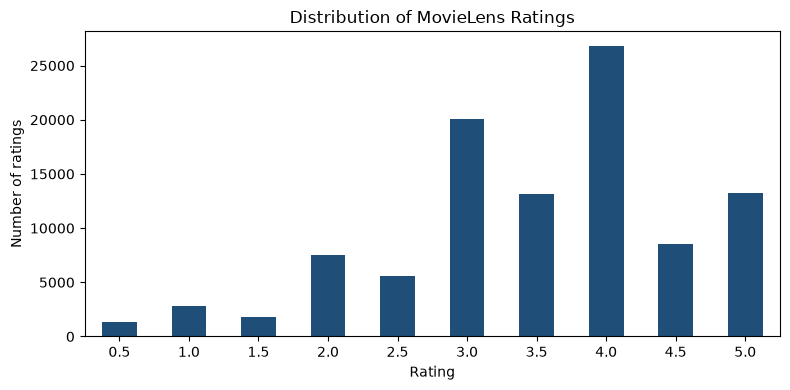

In [4]:
ax = ratings['rating'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8, 4),
    color='#1F4E78',
    rot=0
)
ax.set_title('Distribution of MovieLens Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of ratings')
plt.tight_layout()
plt.show()

## Part 4: Build Movie-Level Statistics

The recommender needs one row per movie with its title, genre labels, rating count, and average rating.

In [5]:
movie_stats = (
    ratings.groupby('movieId')
    .agg(
        rating_count=('rating', 'count'),
        average_rating=('rating', 'mean')
    )
    .reset_index()
    .merge(movies, on='movieId', how='left')
)

movie_stats = movie_stats[['movieId', 'title', 'genres', 'rating_count', 'average_rating']]
movie_stats = movie_stats.sort_values(['rating_count', 'average_rating'], ascending=[False, False])

display(movie_stats.head(10))

,movieId,title,genres,rating_count,average_rating
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
510,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279,4.161290
1938,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446
224,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076
418,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238,3.750000
97,110,Braveheart (1995),Action|Drama|War,237,4.031646
507,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224,3.970982
461,527,Schindler's List (1993),Drama|War,220,4.225000


## Part 5: Minimum-Rating Popularity Baseline

This baseline recommends movies that have enough ratings to be reasonably stable, then sorts by average rating and rating count.

In [6]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10):
    qualified = stats[stats['rating_count'] >= min_ratings].copy()
    recommendations = (
        qualified.sort_values(
            ['average_rating', 'rating_count', 'title'],
            ascending=[False, False, True]
        )
        .head(top_n)
        .reset_index(drop=True)
    )
    return recommendations


recommendations = recommend_popular_movies(movie_stats, min_ratings=50, top_n=10)
display(recommendations[['movieId', 'title', 'genres', 'rating_count', 'average_rating']])

,movieId,title,genres,rating_count,average_rating
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
1,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
3,1276,Cool Hand Luke (1967),Drama,57,4.271930
4,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
5,904,Rear Window (1954),Mystery|Thriller,84,4.261905
6,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
7,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
8,1213,Goodfellas (1990),Crime|Drama,126,4.250000
9,912,Casablanca (1942),Drama|Romance,100,4.240000


## Part 6: Weighted-Rating Baseline

The weighted score reduces the advantage of movies with very high average ratings from a relatively small number of ratings. It combines each movie's average rating with the overall average rating for qualified movies.

In [7]:
C = movie_stats['average_rating'].mean()
m = movie_stats['rating_count'].quantile(0.90)
qualified = movie_stats[movie_stats['rating_count'] >= m].copy()

R = qualified['average_rating']
v = qualified['rating_count']
qualified['weighted_score'] = (
    (v / (v + m)) * R +
    (m / (v + m)) * C
)

weighted_recommendations = (
    qualified.sort_values(
        ['weighted_score', 'rating_count', 'title'],
        ascending=[False, False, True]
    )
    .head(10)
    .reset_index(drop=True)
)

print(f'Overall average rating C: {C:.3f}')
print(f'90th percentile rating-count threshold m: {m:.1f}')
print(f'Qualified movies under weighted method: {len(qualified)}')

display(weighted_recommendations[[
    'movieId', 'title', 'genres', 'rating_count',
    'average_rating', 'weighted_score'
]])

Overall average rating C: 3.262
90th percentile rating-count threshold m: 27.0
Qualified movies under weighted method: 976


,movieId,title,genres,rating_count,average_rating,weighted_score
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.337460
1,858,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.162494
2,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.161576
3,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.137000
4,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.123749
5,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.121515
6,527,Schindler's List (1993),Drama|War,220,4.225000,4.119782
7,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.110118
8,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.107505
9,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134,4.095747


In [8]:
comparison = recommendations[['title', 'rating_count', 'average_rating']].copy()
comparison['method'] = 'Minimum 50 ratings'

weighted_view = weighted_recommendations[[
    'title', 'rating_count', 'average_rating'
]].copy()
weighted_view['method'] = 'Weighted score'

combined_comparison = pd.concat([comparison, weighted_view], ignore_index=True)
display(combined_comparison)

popular_titles = set(recommendations['title'])
weighted_titles = set(weighted_recommendations['title'])
titles_in_both = sorted(popular_titles & weighted_titles)

print('Titles appearing in both lists:')
for title in titles_in_both:
    print('-', title)

print(f'Number of overlapping titles: {len(titles_in_both)}')

,title,rating_count,average_rating,method
0,"Shawshank Redemption, The (1994)",317,4.429022,Minimum 50 ratings
1,"Godfather, The (1972)",192,4.289062,Minimum 50 ratings
2,Fight Club (1999),218,4.272936,Minimum 50 ratings
3,Cool Hand Luke (1967),57,4.271930,Minimum 50 ratings
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Minimum 50 ratings
5,Rear Window (1954),84,4.261905,Minimum 50 ratings
6,"Godfather: Part II, The (1974)",129,4.259690,Minimum 50 ratings
7,"Departed, The (2006)",107,4.252336,Minimum 50 ratings
8,Goodfellas (1990),126,4.250000,Minimum 50 ratings
9,Casablanca (1942),100,4.240000,Minimum 50 ratings


Titles appearing in both lists:
- Fight Club (1999)
- Godfather, The (1972)
- Shawshank Redemption, The (1994)
Number of overlapping titles: 3


The weighted-score method is more conservative about smaller rating counts. The minimum-rating method admits any movie with at least 50 ratings, so a movie can rank highly if it has a very strong average just above that cutoff. The weighted method uses a higher qualifying threshold based on the 90th percentile of rating counts and then pulls each movie's score toward the overall average according to its number of ratings. Neither method is personalized, and neither guarantees diversity or novelty.

## Part 7: Visualize and Test the Output

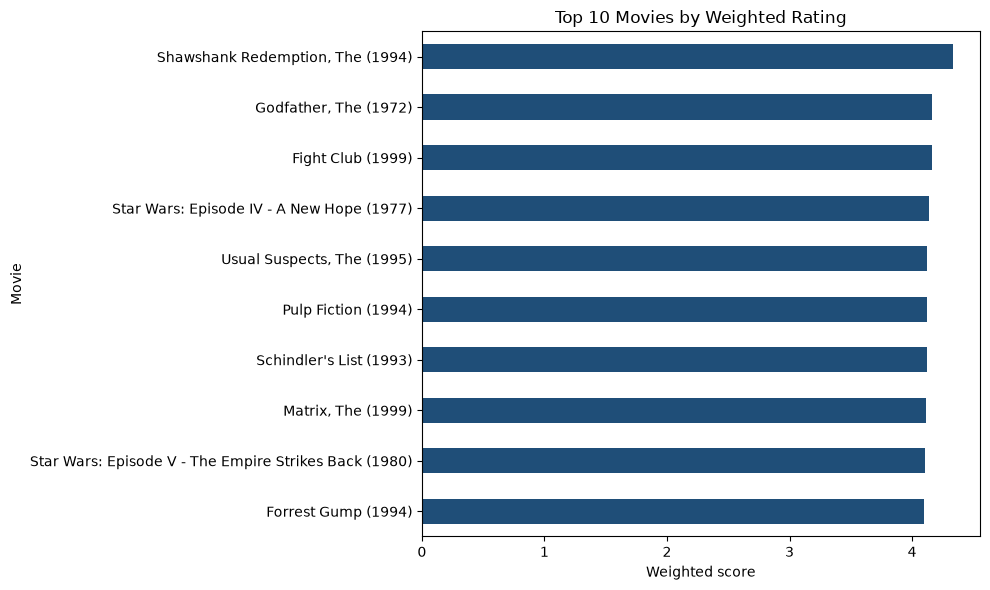

In [9]:
plot_data = weighted_recommendations.sort_values('weighted_score')
ax = plot_data.plot(
    x='title',
    y='weighted_score',
    kind='barh',
    figsize=(10, 6),
    color='#1F4E78',
    legend=False
)
ax.set_title('Top 10 Movies by Weighted Rating')
ax.set_xlabel('Weighted score')
ax.set_ylabel('Movie')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'top10_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
assert len(recommendations) <= 10
assert recommendations['movieId'].is_unique
assert recommendations['rating_count'].ge(50).all()
assert recommendations['average_rating'].between(0.5, 5.0).all()
assert recommendations['title'].notna().all()
assert len(weighted_recommendations) <= 10
assert weighted_recommendations['weighted_score'].notna().all()
print('All checks passed.')

All checks passed.


In [11]:
display(recommend_popular_movies(movie_stats, min_ratings=20, top_n=5))
display(recommend_popular_movies(movie_stats, min_ratings=100, top_n=5))

,movieId,title,genres,rating_count,average_rating
0,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
1,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
2,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
3,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
4,1204,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000


,movieId,title,genres,rating_count,average_rating
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
1,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
3,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
4,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336


Lowering the minimum rating threshold allows more movies to qualify and can surface less widely rated titles. Increasing the threshold favors movies that more users have rated, which usually makes the ranking more stable but can exclude less-known high-quality movies.

In [12]:
def recommend_by_genre(stats, genre, min_ratings=30, top_n=10):
    mask = stats['genres'].str.contains(genre, case=False, na=False)
    return recommend_popular_movies(stats[mask], min_ratings, top_n)


display(recommend_by_genre(movie_stats, 'Comedy', 30, 10))

,movieId,title,genres,rating_count,average_rating
0,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
1,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,142,4.232394
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
3,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,120,4.183333
4,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
5,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,136,4.161765
6,57669,In Bruges (2008),Comedy|Crime|Drama|Thriller,41,4.158537
7,4011,Snatch (2000),Comedy|Crime|Thriller,93,4.155914
8,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,88,4.147727
9,608,Fargo (1996),Comedy|Crime|Drama|Thriller,181,4.116022


The genre filter is still non-personalized because every person requesting Comedy receives the same ranked list. It is a simple contextual filter, not a learned model of user preference.

## Part 8: Interpret the Results

In [13]:
most_rated_movie = movie_stats.sort_values(['rating_count', 'average_rating'], ascending=[False, False]).iloc[0]
first_minimum = recommendations.iloc[0]
first_weighted = weighted_recommendations.iloc[0]

answers = pd.DataFrame({
    'question': [
        'Which movie received the most ratings, and what was its average rating?',
        'Which movie ranked first after applying the 50-rating threshold?',
        'Which movie ranked first using the weighted score?',
        'How many movies qualified under the 90th-percentile threshold?',
        'What changed when the minimum rating threshold was increased?',
        'Why is the resulting list not personalized?',
        'What bias may result from recommending only already-popular movies?',
        'How could the system handle a new movie with no ratings?'
    ],
    'answer': [
        f"{most_rated_movie['title']} received {int(most_rated_movie['rating_count'])} ratings with an average rating of {most_rated_movie['average_rating']:.2f}.",
        f"{first_minimum['title']} ranked first with the 50-rating threshold.",
        f"{first_weighted['title']} ranked first using the weighted score.",
        f"{len(qualified)} movies qualified under the 90th-percentile threshold.",
        'A higher threshold removed less frequently rated movies and favored widely rated titles with more stable averages.',
        'The list is based on aggregate movie popularity, not the tastes or history of a specific user.',
        'Popularity bias can make already famous movies more visible while hiding niche or newer movies.',
        'A new movie could use content features such as genre, tags, cast, or text descriptions until enough ratings are collected.'
    ]
})
display(answers)

,question,answer
0,"Which movie received the most ratings, and wha...",Forrest Gump (1994) received 329 ratings with ...
1,Which movie ranked first after applying the 50...,"Shawshank Redemption, The (1994) ranked first ..."
2,Which movie ranked first using the weighted sc...,"Shawshank Redemption, The (1994) ranked first ..."
3,How many movies qualified under the 90th-perce...,976 movies qualified under the 90th-percentile...
4,What changed when the minimum rating threshold...,A higher threshold removed less frequently rat...
5,Why is the resulting list not personalized?,The list is based on aggregate movie popularit...
6,What bias may result from recommending only al...,Popularity bias can make already famous movies...
7,How could the system handle a new movie with n...,A new movie could use content features such as...


## Findings and Limitations

The MovieLens latest-small data contains a compact but useful set of users, movies, and explicit ratings. The first clear observation is that ratings are unevenly distributed. Some movies receive many ratings, while many others receive only a small number. This matters because a high average rating is more trustworthy when it comes from many users than when it comes from only a few. The sparsity result also shows that most possible user-movie pairs have no rating, which is normal in recommender datasets and explains why recommendation systems need methods that can infer preferences from incomplete information.

The minimum-rating popularity baseline is easy to explain. It filters out movies below a fixed rating-count threshold, then ranks the remaining movies by average rating. This produces a simple Top 10 list, but the result depends heavily on the chosen threshold. A lower threshold can admit less stable titles, while a higher threshold favors widely rated movies and may remove good but less discovered films. The weighted-rating baseline is more conservative because it combines each movie's average rating with the overall average and gives more confidence to movies with many ratings. This reduces the chance that a movie with a small number of unusually high ratings dominates the list.

The main limitation is that neither method is personalized. Every user receives the same recommendations, regardless of their past ratings, favorite genres, or dislikes. A second limitation is popularity bias: already well-known movies become easier to recommend, while new or niche movies get less exposure. A third limitation is the cold-start problem for new movies with no ratings. The methods also ignore time, so they do not adapt to changing popularity or changing user preferences. Finally, a numeric rating does not explain why someone liked a movie, so the model cannot tell whether a user cares about genre, actors, mood, story, or other features.

## Recommended Improvements

- Use genres, tags, titles, or other textual features to build a content-based recommender.
- Use user-rating patterns to build collaborative filtering.
- Split the data into training and test sets and evaluate recommendation quality.
- Add diversity, novelty, and coverage measures rather than optimizing only rating score.
- Include time or recency because preferences and popularity can change.